1. IMPORTS

In [1]:
import numpy as np
import pandas as pd
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


import matplotlib.pyplot as plt



2. LOAD AND CLEAN DATA

In [3]:
df= pd.read_csv("C:\\Users\\HP-PC\\Downloads\\log.csv")
df=df.drop_duplicates()
df.shape

df = df.fillna(df.mean(numeric_only=True))

df = df[df['DPOR'] >= 0]     
df = df[df['CNLS'] >= 0]     
df = df[df['RHOB'] > 0]     
for col in ['GR','RILD','DPOR','RHOB','SP']:
    df[col] = df[col].clip(df[col].quantile(0.01),
                            df[col].quantile(0.99))


print("Data shape after cleaning:", df.shape)
df.head(20)


Data shape after cleaning: (8682, 14)


,Depth,RxoRt,RLL3,SP,RILD,MN,MI,MCAL,DCAL,RHOB,RHOC,DPOR,CNLS,GR
0,195.0,226.0848,0.4076,-26.700287,132.5052,-0.3548,0.1863,5.1090,1.8878,1.6973,-0.6303,59.2216,30.0657,60.4576
1,195.5,223.5031,0.4063,-26.700287,123.6225,-0.3619,0.1867,5.1031,1.8882,1.6791,-0.6409,60.2877,26.7625,54.1495
2,196.0,221.4560,0.4047,-26.700287,116.9258,-0.3668,0.1860,5.0872,1.8878,1.6585,-0.6539,61.4914,27.6017,51.9944
3,196.5,219.8248,0.4033,-26.700287,111.7925,-0.3613,0.1867,5.0881,1.8884,1.6435,-0.6649,62.3711,31.5870,52.9645
4,197.0,218.1438,0.4023,-26.700287,106.7821,-0.3569,0.1870,5.0972,1.8883,1.6390,-0.6705,62.6343,35.8251,54.9659
5,197.5,216.4424,0.4011,-26.700287,101.9883,-0.3565,0.1867,5.1076,1.8888,1.6457,-0.6681,62.2407,37.5462,57.7954
6,198.0,214.9961,0.4004,-26.700287,98.0992,-0.3577,0.1863,5.0938,1.8890,1.6586,-0.6587,61.4837,36.9573,61.2204
7,198.5,213.6405,0.3999,-26.700287,94.6215,-0.3591,0.1844,5.0948,1.8872,1.6702,-0.6479,60.8086,36.0561,62.4314
8,199.0,212.1654,0.3997,-26.700287,91.0034,-0.3598,0.1834,5.0899,1.8864,1.6773,-0.6405,60.3920,35.6943,62.7024
9,199.5,210.7139,0.3997,-26.700287,87.5514,-0.3593,0.1832,5.1075,1.8876,1.6820,-0.6377,60.1187,36.0666,64.5399


3. FEATURE SELECTION 

In [4]:
X = df[['Depth','GR','RILD','DPOR','RHOB','SP']]
# depth GR= gamma ray, RILD = Induction log (resistivity),DPOR =Density Porosity , RHOB= Bulk Density , SP= Sponatneous Potential

import numpy as np

gr_low   = df['GR'].quantile(0.40)     # sand tendency
gr_high  = df['GR'].quantile(0.70)     # shale tendency

res_high = df['RILD'].quantile(0.70)   # high resistivity
res_low  = df['RILD'].quantile(0.30)   # low resistivity

por_high = df['DPOR'].quantile(0.60)   # good porosity
por_low  = df['DPOR'].quantile(0.30)   # poor porosity

den_low  = df['RHOB'].quantile(0.35)   # lighter rock (sand)
den_high = df['RHOB'].quantile(0.75)   # denser rock (shale)

sp_str   = df['SP'].abs().quantile(0.60)  # strong SP deflection


df['sand_score'] = 0


df.loc[df['GR']   < gr_low,   'sand_score'] += 1
df.loc[df['RILD'] > res_high,'sand_score'] += 1
df.loc[df['DPOR'] > por_high,'sand_score'] += 1
df.loc[df['RHOB'] < den_low, 'sand_score'] += 1
df.loc[df['SP'].abs() > sp_str, 'sand_score'] += 1



df.loc[df['GR']   > gr_high,  'sand_score'] -= 1
df.loc[df['RILD'] < res_low, 'sand_score'] -= 1
df.loc[df['DPOR'] < por_low, 'sand_score'] -= 1
df.loc[df['RHOB'] > den_high,'sand_score'] -= 1
df.loc[(df['SP'].abs() < sp_str) & (df['GR'] > gr_high), 'sand_score'] -= 1


df['Facies'] = np.where(df['sand_score'] >= 2,
                        'Sandstone',
                        'Shale')



print(df['Facies'].value_counts())

Facies
Shale        5834
Sandstone    2848
Name: count, dtype: int64


4. LABEL ENCODING

In [5]:
X = df[['Depth','GR', 'DPOR', 'RHOB', 'RILD', 'SP']]
y = df['Facies']


le = LabelEncoder()
le = joblib.load("saved_models/label_encoder.pkl")
y = le.transform(y)

# Sandstone -> 0, Shale -> 1

5. TRAIN - TEST SPLIT

In [6]:
X_train_lr, X_test_lr, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y   
)


6. SCALING

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lr)
X_test_scaled  = scaler.transform(X_test_lr)
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

7. PCA (DIMENSIONALITY REDUCTION)

In [51]:
pca = PCA(n_components=0.98)   

X_train_pca_lr = pca.fit_transform(X_train_scaled)
X_test_pca_lr  = pca.transform(X_test_scaled)

print("Features before PCA:", X_train_lr.shape[1])
print("Features after PCA :", X_train_pca_lr.shape[1])



Features before PCA: 6
Features after PCA : 5


8. GRIDSEARCH

In [52]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 50, 100, 200],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}


grid = GridSearchCV(
    LogisticRegression(solver='liblinear',max_iter=3000, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_lr, y_train)

print("Best C:", grid.best_params_)

log_model = grid.best_estimator_
log_model.fit(X_train_pca_lr, y_train)






Best C: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}


LogisticRegression(C=1, class_weight='balanced', max_iter=3000, penalty='l1',
                   solver='liblinear')

9. PREDICTION

In [54]:

y_pred = log_model.predict(X_test_pca_lr)

10. EVALUATION


In [55]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("\nReport:\n", classification_report(y_test, y_pred_final))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_final))


Accuracy: 0.8932821497120921

Report:
               precision    recall  f1-score   support

           0       0.87      0.80      0.83       855
           1       0.91      0.94      0.92      1750

    accuracy                           0.89      2605
   macro avg       0.89      0.87      0.88      2605
weighted avg       0.89      0.89      0.89      2605


Confusion Matrix:
 [[ 683  172]
 [ 106 1644]]


11. VISUALIZATION

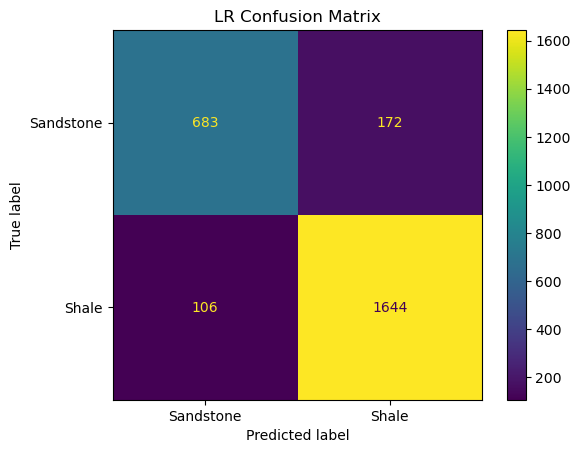

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Sandstone","Shale"])
disp.plot()
plt.title("LR Confusion Matrix")
plt.show()

12. SAVING MODEL


In [57]:


folder_path = os.path.abspath("saved_models")

os.makedirs(folder_path, exist_ok=True)
lr_path = os.path.join(folder_path, "lr.pkl")
joblib.dump(log_model, lr_path)
scaler_path = os.path.join(folder_path, "lr_scaler.pkl")
pca_path = os.path.join(folder_path, "lr_pca.pkl")

joblib.dump(scaler, scaler_path)
joblib.dump(pca, pca_path)

print("Scaler and PCA saved.")


print("Logistic Regression model saved.")


Scaler and PCA saved.
Logistic Regression model saved.


In [ ]:
df['Model'] = 'Logistic Regression'
df.to_csv('lr_output.csv', index=False)

